# Predictfy × Locaweb — Sprint 3 — Deep Learning

**Disciplina:** Artificial Intelligence & Deep Learning Application  
**Projeto e grupo:** Predictfy  
**Turma:** 2TSCPW · FIAP Challenge 2026

| Integrante | RM |
|---|---:|
| Elton Vinicios Almeida de Oliveira | 562187 |
| Emerson dos Santos Silva | 562033 |
| Kelvin Douglas Ribeiro Rabelo | 561538 |
| Pedro Henrique Simão Soares | 562283 |
| Vitor Lucas Mattos de Brito Mariano | 562116 |

## Objetivo

Construir um MVP local de rede neural artificial para **triagem do risco de violação de OLA** em incidentes P2 e P3. A ANN reproduz com Deep Learning a tarefa de classificação hoje atendida pelo XGBoost do Predictfy e é avaliada como candidata em **shadow mode**: seus resultados não alteram o modelo ativo nem automatizam decisões operacionais.

**Pergunta:** uma MLP com dados disponíveis na abertura consegue ordenar incidentes de risco, e incluir o perfil de um K-Means melhora essa ordenação?

## 1. Escopo, fontes e honestidade experimental

Este notebook aproveita a EDA e as regras de segurança do projeto `locaweb`, mas reconstrói o pipeline a partir do XLSX canônico. Não usa o Parquet local antigo, pois ele não contém a coluna de auditoria temporal exigida pelo código atual.

- Ground truth: `KPI Violado?`.
- Campos bloqueados: duração, resolução, encerramento, solução, código de fechamento e o próprio target.
- Treino: aberturas anteriores a 01/07/2025, com resultado conhecido antes do corte.
- Validação de modelo: julho e agosto, somente com resultados conhecidos até 01/09; escolhe arquitetura e uso de cluster.
- Validação de política: setembro, somente com resultados conhecidos até 01/10; define o corte Top‑5% e o threshold de F1 de referência.
- Backtest: outubro a dezembro. O Q4 **não é chamado de teste inédito**, pois já foi analisado pelo projeto.
- PR-AUC é a métrica primária por causa do forte desbalanceamento. Acurácia não seleciona modelos.

In [1]:
import os
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/predictfy-mpl")
os.environ.setdefault("XDG_CACHE_HOME", "/private/tmp/predictfy-cache")

import copy
import json
import math
import pickle
import random
import warnings
from datetime import date

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import xgboost as xgb
from sklearn.cluster import KMeans
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, silhouette_score,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device("cpu")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 80)

print("Python/PyTorch:", torch.__version__, "| dispositivo:", DEVICE)

Python/PyTorch: 2.8.0 | dispositivo: cpu


In [2]:
candidates = []
if os.getenv("PREDICTFY_DATASET"):
    candidates.append(Path(os.environ["PREDICTFY_DATASET"]))
candidates.extend([
    Path("../../locaweb/data/raw/LW-DATASET.xlsx"),
    Path("data/raw/LW-DATASET.xlsx"),
    Path("../../../predictfy-locaweb/locaweb/data/raw/LW-DATASET.xlsx"),
])
DATASET_PATH = next((path.resolve() for path in candidates if path.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError(
        "LW-DATASET.xlsx não encontrado. Defina PREDICTFY_DATASET com o caminho do arquivo oficial."
    )

raw = pd.read_excel(DATASET_PATH)
required = {
    "Aberto", "Resolvido", "Encerrado", "Entrou para KPI?", "KPI Violado?",
    "Prioridade", "Produto", "Categoria", "Subcategoria", "Aberto por",
}
missing = sorted(required - set(raw.columns))
if missing:
    raise ValueError(f"Colunas obrigatórias ausentes: {missing}")

print("Dataset canônico carregado:", DATASET_PATH.name)
print(f"Linhas brutas: {len(raw):,} | colunas: {raw.shape[1]}")

Dataset canônico carregado: LW-DATASET.xlsx
Linhas brutas: 122,543 | colunas: 19


## 2. Pré-processamento para ANN

As features representam informações conhecidas na abertura ou contexto agregado encerrado em D−1. Variáveis categóricas são tratadas como categorias, e não como números ordinais. O `OneHotEncoder` e o `StandardScaler` serão ajustados exclusivamente no treino.

Para aproximar o uso real, registros antigos só entram no treino quando seu desfecho já era conhecido antes do início da validação. Isso evita ensinar a rede com labels que, naquele momento, ainda não existiam.

In [3]:
def periodo_dia(hour):
    if hour < 6: return "madrugada"
    if hour < 12: return "manha"
    if hour < 18: return "tarde"
    return "noite"

df = raw.loc[raw["Entrou para KPI?"].eq("SIM")].copy()
df["Aberto"] = pd.to_datetime(df["Aberto"], errors="coerce")
df["Resolvido"] = pd.to_datetime(df["Resolvido"], errors="coerce")
df["Encerrado"] = pd.to_datetime(df["Encerrado"], errors="coerce")
df["data_resultado"] = df["Resolvido"].fillna(df["Encerrado"])
df = df.dropna(subset=["Aberto"]).sort_values("Aberto", kind="stable").reset_index(drop=True)

unexpected = set(df["Prioridade"].dropna().unique()) - {"2 - Alta", "3 - Média"}
if unexpected:
    raise ValueError(f"Prioridades inesperadas no subset KPI: {unexpected}")

df["target_ola"] = df["KPI Violado?"].eq("SIM").astype(int)
df["data"] = df["Aberto"].dt.normalize()

# Série diária em calendário completo: dias sem incidentes são zeros.
daily = df.groupby("data").size().rename("volume_dia").sort_index().to_frame()
complete_calendar = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
daily = daily.reindex(complete_calendar, fill_value=0)
daily.index.name = "data"
daily["lag_1d"] = daily["volume_dia"].shift(1)
daily["lag_7d"] = daily["volume_dia"].shift(7)
daily["rolling_7d"] = daily["volume_dia"].shift(1).rolling(7, min_periods=1).mean()
daily["rolling_30d"] = daily["volume_dia"].shift(1).rolling(30, min_periods=1).mean()
df = df.merge(daily.drop(columns="volume_dia"), left_on="data", right_index=True, how="left")

br_holidays = holidays.country_holidays("BR", subdiv="SP", years=range(2023, 2027))
df["hora"] = df["Aberto"].dt.hour
df["dia_semana"] = df["Aberto"].dt.dayofweek
df["mes"] = df["Aberto"].dt.month
df["dia_mes"] = df["Aberto"].dt.day
df["semana_ano"] = df["Aberto"].dt.isocalendar().week.astype(int)
df["is_horario_comercial"] = (df["hora"].between(9, 17) & (df["dia_semana"] < 5)).astype(int)
df["is_fim_de_semana"] = (df["dia_semana"] >= 5).astype(int)
df["periodo_dia"] = df["hora"].map(periodo_dia)
df["prioridade"] = df["Prioridade"].map({"2 - Alta": "P2", "3 - Média": "P3"})
df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)
df["is_feriado"] = df["data"].dt.date.map(lambda value: int(value in br_holidays))

# `Aberto por` foi removido: embora disponível na abertura, é identificador
# de alta cardinalidade, traz risco de memorização e privacidade.
categorical = ["prioridade", "Produto", "Categoria", "Subcategoria", "periodo_dia"]
numeric = [
    "hora", "dia_semana", "mes", "dia_mes", "semana_ano",
    "is_horario_comercial", "is_fim_de_semana", "mes_sin", "mes_cos",
    "is_feriado", "lag_1d", "lag_7d", "rolling_7d", "rolling_30d",
]
for column in categorical:
    df[column] = df[column].fillna("DESCONHECIDO").astype(str)

# Contexto operacional point-in-time por grupo: somente contagens encerradas em D-1.
engineered_volume = []
for group_col, prefix in [("Produto", "produto"), ("prioridade", "prioridade")]:
    grouped_daily = df.groupby(["data", group_col]).size().unstack(fill_value=0)
    grouped_daily = grouped_daily.reindex(complete_calendar, fill_value=0)
    for window in (7, 30):
        feature_name = f"{prefix}_volume_{window}d"
        historical = grouped_daily.shift(1).rolling(window, min_periods=1).sum()
        long_feature = historical.stack().rename(feature_name).reset_index()
        long_feature.columns = ["data", group_col, feature_name]
        df = df.merge(long_feature, on=["data", group_col], how="left")
        engineered_volume.append(feature_name)
df["produto_aceleracao_7_30"] = (
    df["produto_volume_7d"] / (df["produto_volume_30d"] * 7 / 30 + 1.0)
)
df["prioridade_aceleracao_7_30"] = (
    df["prioridade_volume_7d"] / (df["prioridade_volume_30d"] * 7 / 30 + 1.0)
)
engineered_volume += ["produto_aceleracao_7_30", "prioridade_aceleracao_7_30"]
df = df.dropna(subset=["lag_1d", "lag_7d", "rolling_7d", "rolling_30d"]).reset_index(drop=True)

model_validation_start = pd.Timestamp("2025-07-01")
threshold_start = pd.Timestamp("2025-09-01")
test_start = pd.Timestamp("2025-10-01")
test_end = pd.Timestamp("2026-01-01")
# Cada janela só pode conter rótulos que já estariam disponíveis no
# instante em que aquela decisão seria tomada. Isso vale também para
# a seleção de arquitetura/cluster, o threshold e o backtest: NaT ou
# um desfecho posterior ao corte não pode contaminar a métrica.
train = df.loc[(df["Aberto"] < model_validation_start) & (df["data_resultado"] < model_validation_start)].copy()
model_validation = df.loc[
    (df["Aberto"] >= model_validation_start)
    & (df["Aberto"] < threshold_start)
    & (df["data_resultado"] < threshold_start)
].copy()
threshold_validation = df.loc[
    (df["Aberto"] >= threshold_start)
    & (df["Aberto"] < test_start)
    & (df["data_resultado"] < test_start)
].copy()
test = df.loc[
    (df["Aberto"] >= test_start)
    & (df["Aberto"] < test_end)
    & (df["data_resultado"] < test_end)
].copy()

audit = pd.DataFrame({
    "periodo": ["treino", "validacao_modelo", "validacao_threshold", "backtest_Q4"],
    "inicio": [train.Aberto.min(), model_validation.Aberto.min(), threshold_validation.Aberto.min(), test.Aberto.min()],
    "fim": [train.Aberto.max(), model_validation.Aberto.max(), threshold_validation.Aberto.max(), test.Aberto.max()],
    "incidentes": [len(train), len(model_validation), len(threshold_validation), len(test)],
    "violacoes": [train.target_ola.sum(), model_validation.target_ola.sum(), threshold_validation.target_ola.sum(), test.target_ola.sum()],
    "prevalencia_pct": [100*train.target_ola.mean(), 100*model_validation.target_ola.mean(), 100*threshold_validation.target_ola.mean(), 100*test.target_ola.mean()],
})
if min(len(train), len(model_validation), len(threshold_validation), len(test)) == 0:
    raise ValueError("Um dos períodos temporais ficou vazio.")
assert train.Aberto.max() < model_validation.Aberto.min()
assert model_validation.Aberto.max() < threshold_validation.Aberto.min()
assert threshold_validation.Aberto.max() < test.Aberto.min()
assert train.data_resultado.max() < model_validation_start
assert model_validation.data_resultado.lt(threshold_start).all()
assert threshold_validation.data_resultado.lt(test_start).all()
assert test.data_resultado.lt(test_end).all()
assert set(df["KPI Violado?"].dropna().unique()) <= {"SIM", "NAO", "NÃO"}
display(audit.style.format({"prevalencia_pct": "{:.3f}%"}))

,periodo,inicio,fim,incidentes,violacoes,prevalencia_pct
0,treino,2023-01-09 21:23:05,2025-06-30 23:08:03,13247,129,0.974%
1,validacao_modelo,2025-07-01 00:30:46,2025-08-31 20:57:38,3978,43,1.081%
2,validacao_threshold,2025-09-01 00:10:16,2025-09-30 21:58:37,2056,9,0.438%
3,backtest_Q4,2025-10-01 00:11:30,2025-12-31 18:06:15,5183,50,0.965%


### Aproveitamento da EDA

O produto já identificou que a violação é rara, P2 possui histórico útil principalmente em 2025 e campos categóricos apresentam ausências informativas. Abaixo reproduzimos as evidências mínimas no dataset efetivamente usado pela ANN.

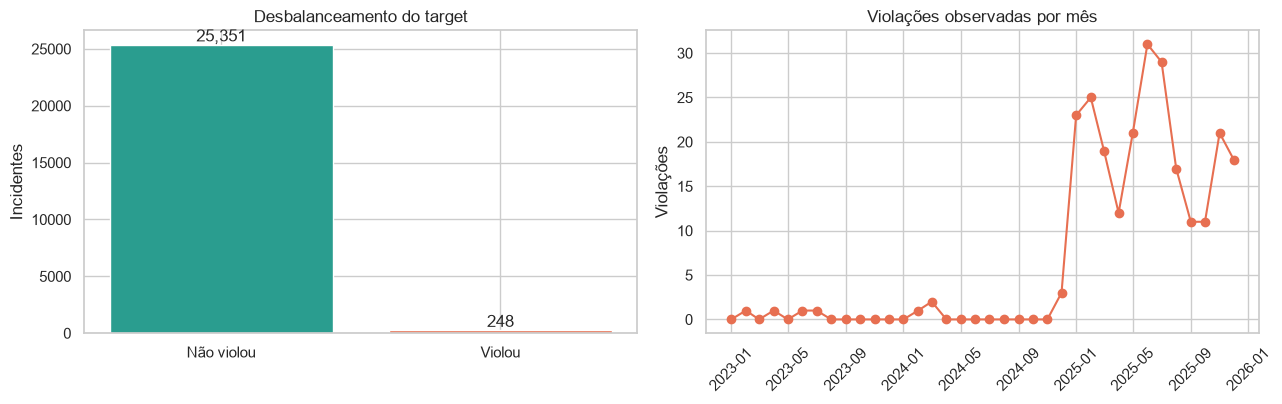

Prevalência global: 0.9688% | razão negativos:positivos = 102.2:1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
counts = df["target_ola"].value_counts().sort_index()
axes[0].bar(["Não violou", "Violou"], counts.values, color=["#2a9d8f", "#e76f51"])
axes[0].set_title("Desbalanceamento do target")
axes[0].set_ylabel("Incidentes")
for i, value in enumerate(counts.values): axes[0].text(i, value, f"{value:,}", ha="center", va="bottom")

monthly = df.set_index("Aberto")["target_ola"].resample("MS").agg(["count", "sum"])
axes[1].plot(monthly.index, monthly["sum"], marker="o", color="#e76f51")
axes[1].set_title("Violações observadas por mês")
axes[1].set_ylabel("Violações")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"Prevalência global: {df.target_ola.mean():.4%} | razão negativos:positivos = {(df.target_ola.eq(0).sum()/df.target_ola.sum()):.1f}:1")

## 3. EDA ampliada e descoberta de padrões

Esta seção segue o roteiro das aulas de EDA: qualidade, análise univariada, relação com o alvo e estabilidade. Para preservar a honestidade experimental, as tabelas capazes de sugerir features são calculadas no **treino**. Validação e Q4 aparecem somente em diagnósticos de drift. Campos posteriores à abertura são examinados apenas para entendimento operacional e continuam bloqueados para modelagem.

,tipo,ausentes,ausentes_pct,valores_unicos
Incidente Pai,str,107416,87.66%,3326
Solução,str,107243,87.51%,2
KPI Violado?,str,96943,79.11%,2
Resolvido,datetime64[us],82302,67.16%,37446
Código de fechamento,str,81739,66.70%,17
Produto,str,77935,63.60%,51
Categoria,str,77721,63.42%,141
Subcategoria,str,77720,63.42%,447
Item de configuração,str,1780,1.45%,9171
Número,str,0,0.00%,122543


Duplicatas exatas no arquivo bruto: 0 (0.000%)


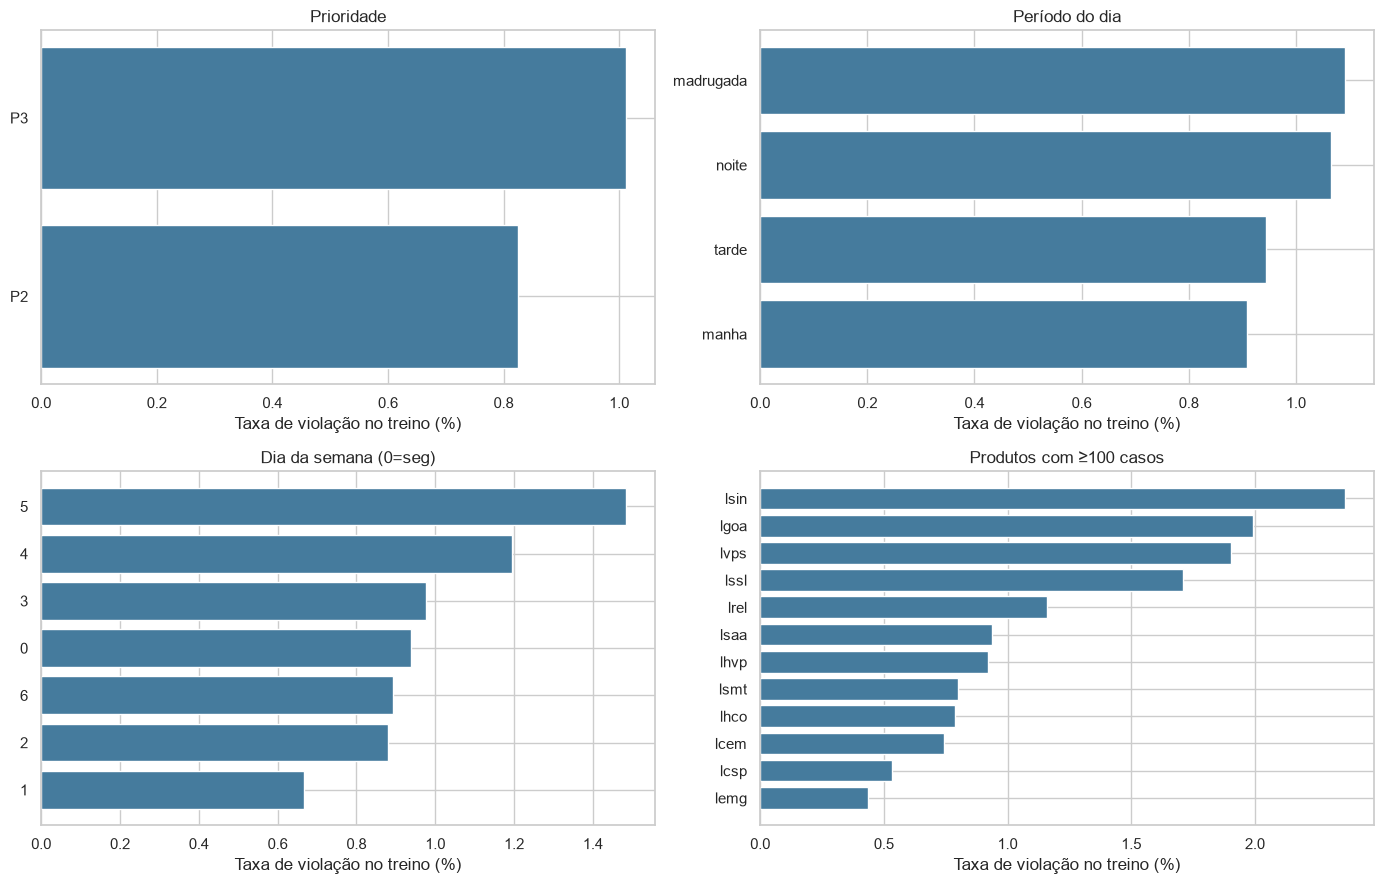

In [5]:
# Qualidade do dado canônico: missing, cardinalidade e duplicação exata.
quality = pd.DataFrame({
    "tipo": raw.dtypes.astype(str),
    "ausentes": raw.isna().sum(),
    "ausentes_pct": 100 * raw.isna().mean(),
    "valores_unicos": raw.nunique(dropna=True),
}).sort_values(["ausentes_pct", "valores_unicos"], ascending=[False, False])
display(quality.style.format({"ausentes_pct": "{:.2f}%"}))
print(f"Duplicatas exatas no arquivo bruto: {raw.duplicated().sum():,} ({raw.duplicated().mean():.3%})")

# Padrões do alvo exclusivamente no treino; grupos muito pequenos não são interpretados.
def risk_by(column, min_count=100):
    result = train.groupby(column, dropna=False).agg(
        incidentes=("target_ola", "size"),
        violacoes=("target_ola", "sum"),
        taxa_violacao=("target_ola", "mean"),
    )
    return result.loc[result.incidentes >= min_count].sort_values("taxa_violacao", ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, column, title in zip(
    axes.ravel(),
    ["prioridade", "periodo_dia", "dia_semana", "Produto"],
    ["Prioridade", "Período do dia", "Dia da semana (0=seg)", "Produtos com ≥100 casos"],
):
    table = risk_by(column).head(12)
    ax.barh(table.index.astype(str), 100 * table.taxa_violacao, color="#457b9d")
    ax.invert_yaxis(); ax.set_title(title); ax.set_xlabel("Taxa de violação no treino (%)")
plt.tight_layout(); plt.show()

top_train_patterns = pd.concat(
    {column: risk_by(column).head(10) for column in ["prioridade", "Produto", "Categoria", "Subcategoria", "periodo_dia"]},
    names=["dimensao", "valor"],
)
display(top_train_patterns.style.format({"taxa_violacao": "{:.3%}"}))

periodo,Q4,jul_ago,setembro
feature,,,
mes,15.958,15.958,15.958
mes_sin,11.677,11.677,11.677
semana_ano,11.431,12.714,12.714
mes_cos,9.093,6.750,11.817
rolling_7d,6.363,1.662,2.744
rolling_30d,4.284,5.245,6.243
lag_1d,1.630,0.296,2.320
lag_7d,0.682,0.269,0.319
dia_mes,0.038,0.016,0.097


periodo,Q4,jul_ago,setembro
feature,,,
Categoria,0.21%,0.08%,0.19%
Produto,0.00%,0.05%,0.00%
Subcategoria,1.25%,1.01%,0.54%
periodo_dia,0.00%,0.00%,0.00%
prioridade,0.00%,0.00%,0.00%


Maior PSI operacional no Q4: rolling_7d (6.363)
Maior taxa categórica inédita no Q4: 1.25%
Nota: PSI alto em mês/semana é esperado em corte temporal e não é, isoladamente, falha do dado.


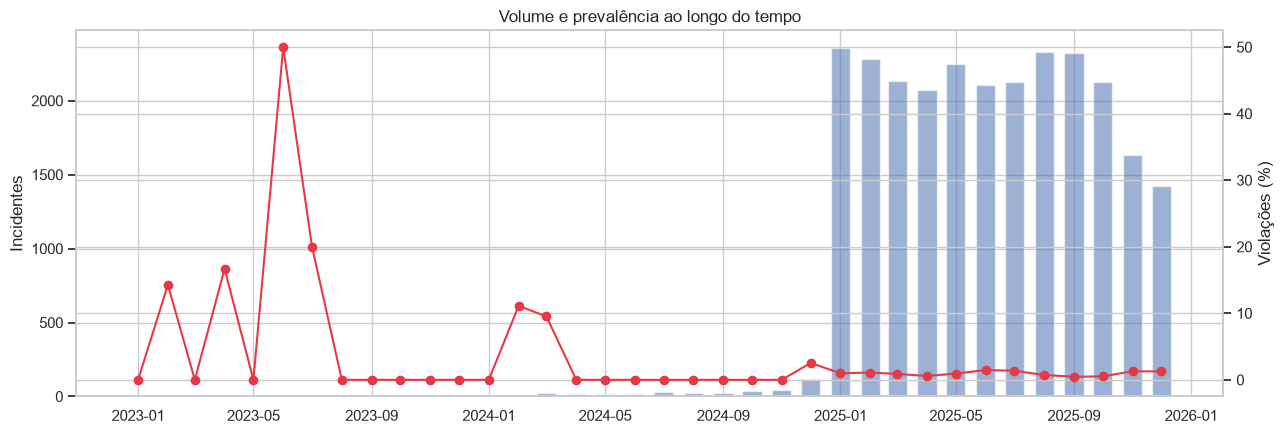

In [6]:
# Drift: PSI numérico usa apenas os cortes quantílicos aprendidos no treino.
def numeric_psi(reference, current, bins=10):
    reference = pd.Series(reference).dropna().astype(float)
    current = pd.Series(current).dropna().astype(float)
    edges = np.unique(reference.quantile(np.linspace(0, 1, bins + 1)).to_numpy())
    if len(edges) < 3: return np.nan
    edges[0], edges[-1] = -np.inf, np.inf
    ref = pd.cut(reference, edges, include_lowest=True).value_counts(normalize=True, sort=False).clip(1e-6)
    cur = pd.cut(current, edges, include_lowest=True).value_counts(normalize=True, sort=False).clip(1e-6)
    return float(((cur - ref) * np.log(cur / ref)).sum())

drift_rows = []
for period, frame in [("jul_ago", model_validation), ("setembro", threshold_validation), ("Q4", test)]:
    for feature in numeric:
        drift_rows.append({"periodo": period, "feature": feature, "metrica": "PSI", "valor": numeric_psi(train[feature], frame[feature])})
drift_numeric = pd.DataFrame(drift_rows)
drift_pivot = drift_numeric.pivot(index="feature", columns="periodo", values="valor").sort_values("Q4", ascending=False)
display(drift_pivot.style.format("{:.3f}").background_gradient(cmap="YlOrRd", axis=None))

# Cobertura categórica: proporção futura pertencente a categorias nunca vistas no treino.
unseen_rows = []
for period, frame in [("jul_ago", model_validation), ("setembro", threshold_validation), ("Q4", test)]:
    for feature in categorical:
        known = set(train[feature].astype(str))
        unseen_rows.append({
            "periodo": period, "feature": feature,
            "taxa_categoria_inedita": float((~frame[feature].astype(str).isin(known)).mean()),
            "cardinalidade": int(frame[feature].nunique()),
        })
unseen_df = pd.DataFrame(unseen_rows)
display(unseen_df.pivot(index="feature", columns="periodo", values="taxa_categoria_inedita")
        .style.format("{:.2%}").background_gradient(cmap="Blues", axis=None))
operational_features = ["lag_1d", "lag_7d", "rolling_7d", "rolling_30d", "hora", "dia_semana"]
q4_operational_drift = drift_pivot.loc[operational_features, "Q4"].sort_values(ascending=False)
print("Maior PSI operacional no Q4:", q4_operational_drift.index[0], f"({q4_operational_drift.iloc[0]:.3f})")
print("Maior taxa categórica inédita no Q4:",
      f"{unseen_df.loc[unseen_df.periodo.eq('Q4')].sort_values('taxa_categoria_inedita').iloc[-1].taxa_categoria_inedita:.2%}")
print("Nota: PSI alto em mês/semana é esperado em corte temporal e não é, isoladamente, falha do dado.")

monthly_diagnostic = df.set_index("Aberto").resample("MS").agg(
    incidentes=("target_ola", "size"), violacoes=("target_ola", "sum"), prevalencia=("target_ola", "mean")
)
fig, ax1 = plt.subplots(figsize=(13, 4.5)); ax2 = ax1.twinx()
ax1.bar(monthly_diagnostic.index, monthly_diagnostic.incidentes, width=20, alpha=.55, label="Incidentes")
ax2.plot(monthly_diagnostic.index, 100*monthly_diagnostic.prevalencia, color="#e63946", marker="o", label="Prevalência")
ax1.set_ylabel("Incidentes"); ax2.set_ylabel("Violações (%)"); ax1.set_title("Volume e prevalência ao longo do tempo")
plt.tight_layout(); plt.show()

In [7]:
# Análise pós-incidente, estritamente descritiva: duração jamais entra em X.
resolved_mask = df["data_resultado"].notna() & (df["data_resultado"] >= df["Aberto"])
post_outcome = df.loc[resolved_mask, ["prioridade", "target_ola", "Aberto", "data_resultado"]].copy()
post_outcome["duracao_horas"] = (post_outcome.data_resultado - post_outcome.Aberto).dt.total_seconds() / 3600
duration_summary = post_outcome.groupby(["prioridade", "target_ola"]).duracao_horas.agg(
    casos="size", mediana="median", p90=lambda values: values.quantile(.90), p99=lambda values: values.quantile(.99)
)
display(duration_summary.style.format({"mediana": "{:.1f} h", "p90": "{:.1f} h", "p99": "{:.1f} h"}))
print("AVISO: duração e data de resultado são posteriores à abertura e não participam do modelo.")

AVISO: duração e data de resultado são posteriores à abertura e não participam do modelo.


## 4. Avaliação da clusterização

O K-Means não utiliza o target. Ele é ajustado apenas com variáveis numéricas do treino e serve como hipótese de *feature engineering*. Avaliamos K de 2 a 10 por Silhouette no treino. Depois atribuímos o cluster mais próximo aos períodos futuros, sem reajustar centroides.

Cluster é associação estatística, não causa raiz. Ele só permanecerá na ANN se elevar a PR-AUC de validação em pelo menos 0,002 absoluto.

In [8]:
cluster_features = [
    "hora", "dia_semana", "mes", "is_horario_comercial", "is_fim_de_semana",
    "is_feriado", "lag_1d", "rolling_7d", "rolling_30d",
]
cluster_scaler = StandardScaler().fit(train[cluster_features])
X_cluster_train = cluster_scaler.transform(train[cluster_features])
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(train), min(6000, len(train)), replace=False)
cluster_trials = []
for k in range(2, 11):
    candidate = KMeans(n_clusters=k, random_state=SEED, n_init=20).fit(X_cluster_train)
    score = silhouette_score(X_cluster_train[sample_idx], candidate.labels_[sample_idx])
    cluster_trials.append({"k": k, "silhouette_treino": score, "modelo": candidate})

cluster_table = pd.DataFrame([{k: v for k, v in item.items() if k != "modelo"} for item in cluster_trials])
best_cluster_trial = max(cluster_trials, key=lambda item: item["silhouette_treino"])
kmeans = best_cluster_trial["modelo"]
display(cluster_table.style.format({"silhouette_treino": "{:.4f}"}))
print("K selecionado exclusivamente no treino:", best_cluster_trial["k"])

for frame in (train, model_validation, threshold_validation, test):
    frame["cluster_operacional"] = kmeans.predict(cluster_scaler.transform(frame[cluster_features])).astype(str)

profile = train.groupby("cluster_operacional").agg(
    incidentes=("target_ola", "size"),
    violacoes=("target_ola", "sum"),
    taxa_violacao=("target_ola", "mean"),
    hora_media=("hora", "mean"),
    volume_rolling_7d=("rolling_7d", "mean"),
)
display(profile.style.format({"taxa_violacao": "{:.3%}", "hora_media": "{:.1f}", "volume_rolling_7d": "{:.1f}"}))

cluster_mix = pd.DataFrame({
    "treino": train.cluster_operacional.value_counts(normalize=True),
    "jul_ago": model_validation.cluster_operacional.value_counts(normalize=True),
    "setembro": threshold_validation.cluster_operacional.value_counts(normalize=True),
    "Q4": test.cluster_operacional.value_counts(normalize=True),
}).fillna(0).sort_index()
display(cluster_mix.style.format("{:.2%}").background_gradient(cmap="Blues", axis=None))
print("Perfis são descritivos: diferenças de taxa não estabelecem causalidade.")

,k,silhouette_treino
0,2,0.3288
1,3,0.3541
2,4,0.3708
3,5,0.2675
4,6,0.3100
5,7,0.3169
6,8,0.3216
7,9,0.2990
8,10,0.2965


K selecionado exclusivamente no treino: 4


,incidentes,violacoes,taxa_violacao,hora_media,volume_rolling_7d
cluster_operacional,,,,,
0,802,13,1.621%,13.5,21.1
1,10452,94,0.899%,12.8,75.1
2,1860,21,1.129%,11.4,74.9
3,133,1,0.752%,10.9,59.7


,treino,jul_ago,setembro,Q4
cluster_operacional,,,,
0,6.05%,0.00%,0.00%,3.26%
1,78.90%,85.44%,86.87%,81.28%
2,14.04%,13.02%,12.35%,12.75%
3,1.00%,1.53%,0.78%,2.70%


Perfis são descritivos: diferenças de taxa não estabelecem causalidade.


## 5. Camada de entrada e arquitetura da rede

A camada de entrada recebe o vetor produzido por:

1. padronização das 14 variáveis numéricas;
2. one-hot das cinco variáveis categóricas, sem identificadores pessoais;
3. opcionalmente, one-hot do cluster operacional.

Cada arquitetura usa blocos `Linear → ReLU → Dropout`. A saída contém um logit; `sigmoid` é aplicada apenas para obter o score. A `BCEWithLogitsLoss` recebe `pos_weight` calculado no treino para que a classe rara tenha peso proporcional.

```text
input (N features) → Dense/ReLU/Dropout → ... → Dense(1 logit)
```

In [9]:
def make_preprocessor(include_cluster=False):
    cat = categorical + (["cluster_operacional"] if include_cluster else [])
    return ColumnTransformer([
        ("numeric", StandardScaler(), numeric),
        ("categorical", OneHotEncoder(handle_unknown="ignore", min_frequency=3, sparse_output=False), cat),
    ], remainder="drop", verbose_feature_names_out=False)

preprocessors = {}
arrays = {}
for mode, include_cluster in (("sem_cluster", False), ("com_cluster", True)):
    transformer = make_preprocessor(include_cluster)
    X_train = transformer.fit_transform(train).astype("float32")
    X_model_validation = transformer.transform(model_validation).astype("float32")
    X_threshold_validation = transformer.transform(threshold_validation).astype("float32")
    X_test = transformer.transform(test).astype("float32")
    preprocessors[mode] = transformer
    arrays[mode] = (X_train, X_model_validation, X_threshold_validation, X_test)
    print(f"{mode}: camada de entrada com {X_train.shape[1]} features")

y_train = train.target_ola.to_numpy(dtype="float32")
y_model_validation = model_validation.target_ola.to_numpy(dtype="float32")
y_threshold_validation = threshold_validation.target_ola.to_numpy(dtype="float32")
y_test = test.target_ola.to_numpy(dtype="float32")

sem_cluster: camada de entrada com 349 features
com_cluster: camada de entrada com 353 features


## 6. Implementação e treinamento do modelo

In [10]:
class RiskMLP(nn.Module):
    def __init__(self, input_size, hidden_layers, dropout):
        super().__init__()
        layers = []
        previous = input_size
        for width in hidden_layers:
            layers.extend([nn.Linear(previous, width), nn.ReLU(), nn.Dropout(dropout)])
            previous = width
        layers.append(nn.Linear(previous, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)

ARCHITECTURES = {
    "compacta_64_32": {"hidden": [64, 32], "dropout": 0.20},
    "balanceada_128_64": {"hidden": [128, 64], "dropout": 0.30},
    "profunda_128_64_32": {"hidden": [128, 64, 32], "dropout": 0.40},
}

def predict_scores(model, X):
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X).to(DEVICE))
        return torch.sigmoid(logits).cpu().numpy()

def predict_ensemble(models, X):
    return np.mean([predict_scores(model, X) for model in models], axis=0)

def train_model(X_train, y_train, X_validation, y_validation, config, seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    model = RiskMLP(X_train.shape[1], config["hidden"], config["dropout"]).to(DEVICE)
    positives = float(y_train.sum())
    negatives = float(len(y_train) - positives)
    pos_weight = torch.tensor([negatives / positives], dtype=torch.float32, device=DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
        batch_size=256, shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    best_pr_auc, best_state, wait = -np.inf, None, 0
    history = {"loss": [], "val_pr_auc": []}
    for epoch in range(1, 81):
        model.train(); epoch_loss = 0.0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch.to(DEVICE)), y_batch.to(DEVICE))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(X_batch)
        scores = predict_scores(model, X_validation)
        val_pr_auc = average_precision_score(y_validation, scores)
        history["loss"].append(epoch_loss / len(X_train))
        history["val_pr_auc"].append(val_pr_auc)
        if val_pr_auc > best_pr_auc + 1e-5:
            best_pr_auc = val_pr_auc
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= 10: break
    model.load_state_dict(best_state)
    return model, history, float(best_pr_auc), epoch

### Testes de parametrização

As três configurações foram definidas antes do backtest. Cada configuração é treinada com seeds 11, 42 e 101; a seleção usa a média de PR-AUC de julho-agosto. Depois repetimos as três seeds com cluster para medir sua utilidade incremental.

In [11]:
models = {}
histories = {}
trials = []
SEEDS = [11, 42, 101]
Xtr, Xva, _, _ = arrays["sem_cluster"]
for name, config in ARCHITECTURES.items():
    seed_runs = [train_model(Xtr, y_train, Xva, y_model_validation, config, seed) for seed in SEEDS]
    models[(name, "sem_cluster")] = [run[0] for run in seed_runs]
    histories[(name, "sem_cluster")] = [run[1] for run in seed_runs]
    seed_scores = [run[2] for run in seed_runs]
    trials.append({
        "arquitetura": name, "cluster": "não", "entrada": Xtr.shape[1],
        "parametros": sum(p.numel() for p in seed_runs[0][0].parameters()),
        "epocas_media": np.mean([run[3] for run in seed_runs]),
        "pr_auc_media": np.mean(seed_scores), "pr_auc_desvio": np.std(seed_scores),
        "pr_auc_pior_seed": np.min(seed_scores),
    })

best_architecture = max(trials, key=lambda item: item["pr_auc_media"])["arquitetura"]
Xtr_c, Xva_c, _, _ = arrays["com_cluster"]
cluster_runs = [
    train_model(Xtr_c, y_train, Xva_c, y_model_validation, ARCHITECTURES[best_architecture], seed)
    for seed in SEEDS
]
models[(best_architecture, "com_cluster")] = [run[0] for run in cluster_runs]
histories[(best_architecture, "com_cluster")] = [run[1] for run in cluster_runs]
cluster_scores = [run[2] for run in cluster_runs]
trials.append({
    "arquitetura": best_architecture, "cluster": "sim", "entrada": Xtr_c.shape[1],
    "parametros": sum(p.numel() for p in cluster_runs[0][0].parameters()),
    "epocas_media": np.mean([run[3] for run in cluster_runs]),
    "pr_auc_media": np.mean(cluster_scores), "pr_auc_desvio": np.std(cluster_scores),
    "pr_auc_pior_seed": np.min(cluster_scores),
})

trials_df = pd.DataFrame(trials).sort_values("pr_auc_media", ascending=False)
display(trials_df.style.format({
    "epocas_media": "{:.1f}", "pr_auc_media": "{:.5f}",
    "pr_auc_desvio": "{:.5f}", "pr_auc_pior_seed": "{:.5f}",
}))

,arquitetura,cluster,entrada,parametros,epocas_media,pr_auc_media,pr_auc_desvio,pr_auc_pior_seed
0,compacta_64_32,não,349,24513,24.3,0.07530,0.00560,0.06946
3,compacta_64_32,sim,353,24769,23.3,0.07279,0.00031,0.07248
1,balanceada_128_64,não,349,53121,18.7,0.07266,0.00271,0.06883
2,profunda_128_64_32,não,349,55169,23.7,0.06543,0.00587,0.06118


Arquitetura selecionada: compacta_64_32
Delta PR-AUC do cluster: -0.00252
Decisão sobre cluster: REJEITADO


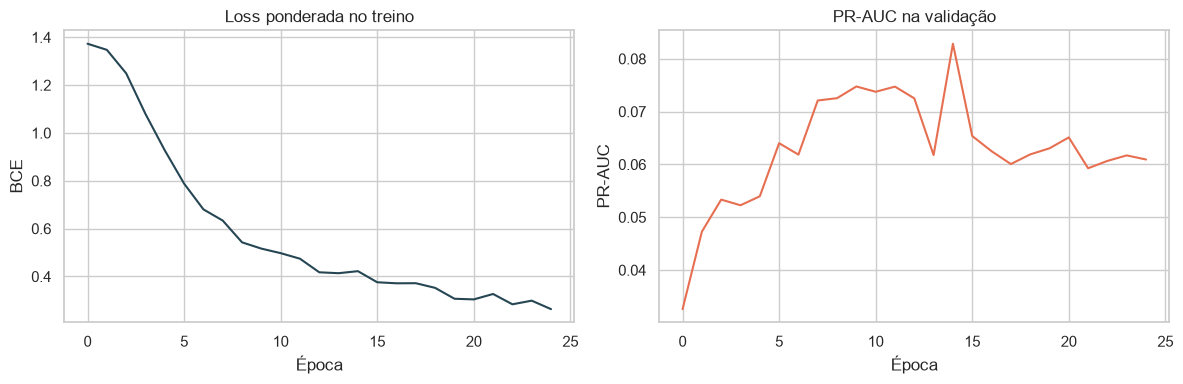

In [12]:
base_pr_auc = next(
    item["pr_auc_media"] for item in trials
    if item["arquitetura"] == best_architecture and item["cluster"] == "não"
)
cluster_pr_auc = float(np.mean(cluster_scores))
cluster_gain = cluster_pr_auc - base_pr_auc
use_cluster = cluster_gain >= 0.002
selected_mode = "com_cluster" if use_cluster else "sem_cluster"
selected_models = models[(best_architecture, selected_mode)]
selected_preprocessor = preprocessors[selected_mode]

print("Arquitetura selecionada:", best_architecture)
print(f"Delta PR-AUC do cluster: {cluster_gain:+.5f}")
print("Decisão sobre cluster:", "MANTIDO" if use_cluster else "REJEITADO")

history = histories[(best_architecture, selected_mode)][0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"], color="#264653")
axes[0].set(title="Loss ponderada no treino", xlabel="Época", ylabel="BCE")
axes[1].plot(history["val_pr_auc"], color="#e76f51")
axes[1].set(title="PR-AUC na validação", xlabel="Época", ylabel="PR-AUC")
plt.tight_layout(); plt.show()

## 7. Avaliação de desempenho

In [13]:
def choose_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    p, r = precision[:-1], recall[:-1]
    f1 = 2 * p * r / (p + r + 1e-12)
    f1_idx = int(np.argmax(f1))
    return float(thresholds[f1_idx])

def evaluate_threshold(y_true, scores, threshold):
    prediction = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    prevalence = float(np.mean(y_true))
    return {
        "pr_auc": average_precision_score(y_true, scores),
        "roc_auc": roc_auc_score(y_true, scores),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "alertas": int(prediction.sum()),
        "taxa_alertas": float(prediction.mean()),
        "lift_politica": float(precision_score(y_true, prediction, zero_division=0) / prevalence) if prevalence else np.nan,
        "revisoes_por_acerto": float(prediction.sum() / tp) if tp else np.inf,
    }

_, X_model_validation_selected, X_threshold_selected, X_test_selected = arrays[selected_mode]
model_validation_scores = predict_ensemble(selected_models, X_model_validation_selected)
threshold_validation_scores = predict_ensemble(selected_models, X_threshold_selected)
threshold_top5 = float(np.quantile(threshold_validation_scores, 0.95))
threshold_f1 = choose_f1_threshold(y_threshold_validation, threshold_validation_scores)
test_scores = predict_ensemble(selected_models, X_test_selected)

rows = []
for period, y_true, scores in (
    ("validacao_threshold_setembro", y_threshold_validation, threshold_validation_scores),
    ("backtest_Q4", y_test, test_scores),
):
    for policy, threshold in (("capacidade_top5", threshold_top5), ("f1_referencia", threshold_f1)):
        rows.append({"periodo": period, "politica": policy, "threshold": threshold, **evaluate_threshold(y_true, scores, threshold)})
metrics_df = pd.DataFrame(rows)
display(metrics_df.style.format({
    "threshold": "{:.5f}", "pr_auc": "{:.5f}", "roc_auc": "{:.5f}",
    "precision": "{:.3%}", "recall": "{:.3%}", "f1": "{:.5f}",
    "taxa_alertas": "{:.3%}", "lift_politica": "{:.2f}×", "revisoes_por_acerto": "{:.1f}",
}))

,periodo,politica,threshold,pr_auc,roc_auc,precision,recall,f1,tp,fp,fn,tn,alertas,taxa_alertas,lift_politica,revisoes_por_acerto
0,validacao_threshold_setembro,capacidade_top5,0.47048,0.12580,0.61488,1.923%,22.222%,0.03540,2,102,7,1945,104,5.058%,4.39×,52.0
1,validacao_threshold_setembro,f1_referencia,0.98379,0.12580,0.61488,100.000%,11.111%,0.20000,1,0,8,2047,1,0.049%,228.44×,1.0
2,backtest_Q4,capacidade_top5,0.47048,0.11127,0.71969,6.667%,38.000%,0.11343,19,266,31,4867,285,5.499%,6.91×,15.0
3,backtest_Q4,f1_referencia,0.98379,0.11127,0.71969,50.000%,2.000%,0.03846,1,1,49,5132,2,0.039%,51.83×,2.0


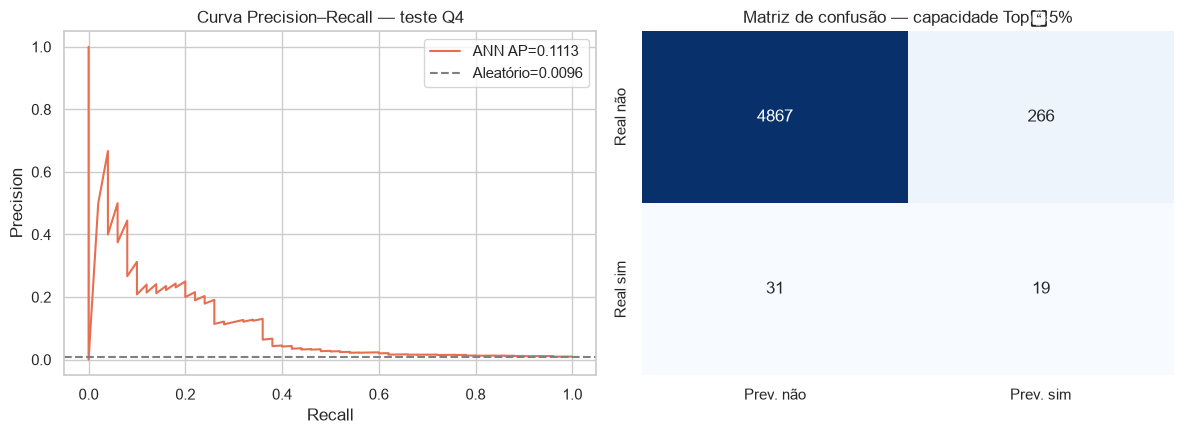

In [14]:
precision, recall, _ = precision_recall_curve(y_test, test_scores)
capacity_metrics = evaluate_threshold(y_test, test_scores, threshold_top5)
matrix = np.array([[capacity_metrics["tn"], capacity_metrics["fp"]], [capacity_metrics["fn"], capacity_metrics["tp"]]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(recall, precision, color="#e76f51", label=f"ANN AP={capacity_metrics['pr_auc']:.4f}")
axes[0].axhline(y_test.mean(), color="gray", linestyle="--", label=f"Aleatório={y_test.mean():.4f}")
axes[0].set(title="Curva Precision–Recall — teste Q4", xlabel="Recall", ylabel="Precision")
axes[0].legend()
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=["Prev. não", "Prev. sim"], yticklabels=["Real não", "Real sim"])
axes[1].set_title("Matriz de confusão — capacidade Top‑5%")
plt.tight_layout(); plt.show()

### Comparação com o produto atual

Para evitar uma comparação injusta com o JSON histórico, treinamos um XGBoost de referência nas **mesmas linhas e mesmas features transformadas** da ANN. Ambos usam setembro apenas para definir a capacidade Top‑5% e são avaliados no mesmo backtest Q4. O JSON do modelo ativo permanece apenas como contexto de produto.

In [15]:
X_train_selected, _, X_threshold_selected, X_test_selected = arrays[selected_mode]
scale_pos_weight = float((len(y_train) - y_train.sum()) / y_train.sum())
paired_xgb = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_lambda=3.0, scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr", random_state=SEED, n_jobs=-1, tree_method="hist",
)
paired_xgb.fit(X_train_selected, y_train)
xgb_threshold_scores = paired_xgb.predict_proba(X_threshold_selected)[:, 1]
xgb_test_scores = paired_xgb.predict_proba(X_test_selected)[:, 1]
xgb_top5_threshold = float(np.quantile(xgb_threshold_scores, 0.95))

ann_test = evaluate_threshold(y_test, test_scores, threshold_top5)
xgb_test = evaluate_threshold(y_test, xgb_test_scores, xgb_top5_threshold)
comparison = [
    {"modelo": "ANN ensemble (3 seeds)", **ann_test},
    {"modelo": "XGBoost pareado", **xgb_test},
]
comparison_df = pd.DataFrame(comparison)
display(comparison_df.style.format({
    "pr_auc": "{:.5f}", "roc_auc": "{:.5f}", "precision": "{:.3%}",
    "recall": "{:.3%}", "f1": "{:.5f}", "taxa_alertas": "{:.3%}",
    "lift_politica": "{:.2f}×", "revisoes_por_acerto": "{:.1f}",
}))

# Bootstrap pareado: incerteza do delta de PR-AUC no mesmo Q4.
boot_rng = np.random.default_rng(2026)
deltas = []
for _ in range(1000):
    idx = boot_rng.integers(0, len(y_test), len(y_test))
    if len(np.unique(y_test[idx])) < 2: continue
    deltas.append(
        average_precision_score(y_test[idx], test_scores[idx])
        - average_precision_score(y_test[idx], xgb_test_scores[idx])
    )
delta_ci = np.quantile(deltas, [0.025, 0.5, 0.975])
print(f"Delta PR-AUC ANN−XGBoost: mediana={delta_ci[1]:+.5f} | IC95% bootstrap [{delta_ci[0]:+.5f}, {delta_ci[2]:+.5f}]")

,modelo,pr_auc,roc_auc,precision,recall,f1,tp,fp,fn,tn,alertas,taxa_alertas,lift_politica,revisoes_por_acerto
0,ANN ensemble (3 seeds),0.11127,0.71969,6.667%,38.000%,0.11343,19,266,31,4867,285,5.499%,6.91×,15.0
1,XGBoost pareado,0.20947,0.69807,6.227%,34.000%,0.10526,17,256,33,4877,273,5.267%,6.46×,16.1


Delta PR-AUC ANN−XGBoost: mediana=-0.08786 | IC95% bootstrap [-0.17578, -0.01094]


### Diagnóstico ampliado do modelo

As análises abaixo são retrospectivas. Elas explicam estabilidade, erros e custo operacional, mas não reabrem a seleção da arquitetura nem alteram o threshold já congelado em setembro.

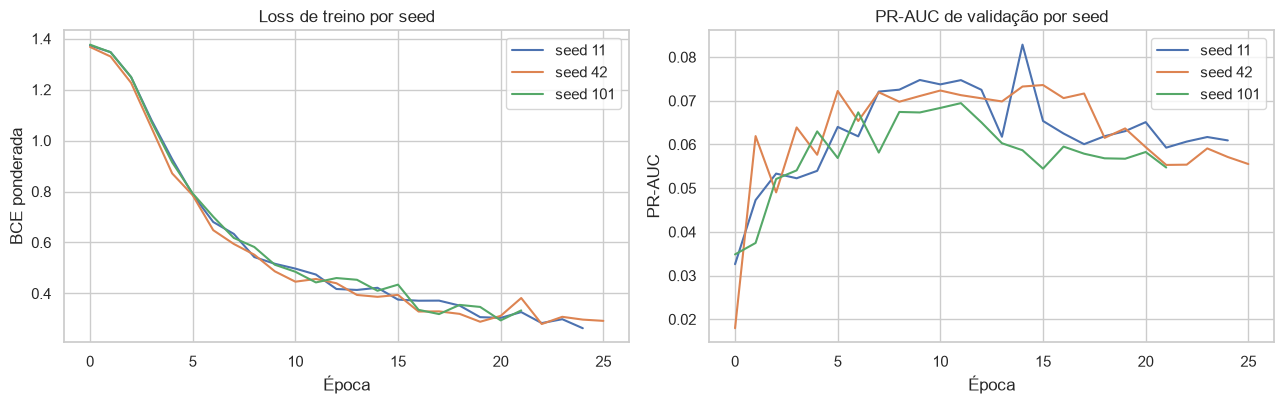

,seed,pr_auc_Q4,roc_auc_Q4,score_medio,score_desvio
0,11,0.07882,0.72372,0.09889,0.19326
1,42,0.12805,0.71141,0.06766,0.15087
2,101,0.11542,0.70851,0.12991,0.20347


In [16]:
# Curvas das três seeds: evidencia dispersão e possível overfitting.
selected_histories = histories[(best_architecture, selected_mode)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for seed, run_history in zip(SEEDS, selected_histories):
    axes[0].plot(run_history["loss"], label=f"seed {seed}")
    axes[1].plot(run_history["val_pr_auc"], label=f"seed {seed}")
axes[0].set(title="Loss de treino por seed", xlabel="Época", ylabel="BCE ponderada")
axes[1].set(title="PR-AUC de validação por seed", xlabel="Época", ylabel="PR-AUC")
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

seed_stability = []
for seed, model in zip(SEEDS, selected_models):
    scores = predict_scores(model, X_test_selected)
    seed_stability.append({
        "seed": seed, "pr_auc_Q4": average_precision_score(y_test, scores),
        "roc_auc_Q4": roc_auc_score(y_test, scores),
        "score_medio": scores.mean(), "score_desvio": scores.std(),
    })
display(pd.DataFrame(seed_stability).style.format({
    "pr_auc_Q4": "{:.5f}", "roc_auc_Q4": "{:.5f}", "score_medio": "{:.5f}", "score_desvio": "{:.5f}"
}))

In [17]:
# Sensibilidade à capacidade: cada threshold é calibrado em setembro e congelado antes do Q4.
capacity_rows = []
for top_pct in [1, 3, 5, 10]:
    threshold = float(np.quantile(threshold_validation_scores, 1 - top_pct / 100))
    capacity_rows.append({"capacidade_nominal": f"Top-{top_pct}%", "threshold_setembro": threshold,
                          **evaluate_threshold(y_test, test_scores, threshold)})
capacity_df = pd.DataFrame(capacity_rows)
display(capacity_df.style.format({
    "threshold_setembro": "{:.5f}", "precision": "{:.3%}", "recall": "{:.3%}", "f1": "{:.5f}",
    "taxa_alertas": "{:.3%}", "lift_politica": "{:.2f}×", "revisoes_por_acerto": "{:.1f}",
    "pr_auc": "{:.5f}", "roc_auc": "{:.5f}",
}))

# Incerteza das métricas operacionais da política principal.
bootstrap_metrics = []
boot_rng_metrics = np.random.default_rng(562033)
for _ in range(1000):
    idx = boot_rng_metrics.integers(0, len(y_test), len(y_test))
    if len(np.unique(y_test[idx])) < 2: continue
    item = evaluate_threshold(y_test[idx], test_scores[idx], threshold_top5)
    bootstrap_metrics.append([item["pr_auc"], item["precision"], item["recall"], item["f1"]])
bootstrap_metrics = np.asarray(bootstrap_metrics)
metric_ci = pd.DataFrame(
    np.quantile(bootstrap_metrics, [.025, .5, .975], axis=0).T,
    index=["PR-AUC", "Precisão Top-5%", "Recall Top-5%", "F1 Top-5%"],
    columns=["IC95_inf", "mediana", "IC95_sup"],
)
display(metric_ci.style.format("{:.5f}"))
best_retrospective = capacity_df.loc[capacity_df.f1.idxmax()]
print(
    "Leitura retrospectiva: o", best_retrospective.capacidade_nominal,
    f"teve o maior F1 ({best_retrospective.f1:.4f}), mas isso não substitui a política Top-5% já congelada."
)

,capacidade_nominal,threshold_setembro,pr_auc,roc_auc,precision,recall,f1,tp,fp,fn,tn,alertas,taxa_alertas,lift_politica,revisoes_por_acerto
0,Top-1%,0.84279,0.11127,0.71969,23.077%,18.000%,0.20225,9,30,41,5103,39,0.752%,23.92×,4.3
1,Top-3%,0.65608,0.11127,0.71969,12.403%,32.000%,0.17877,16,113,34,5020,129,2.489%,12.86×,8.1
2,Top-5%,0.47048,0.11127,0.71969,6.667%,38.000%,0.11343,19,266,31,4867,285,5.499%,6.91×,15.0
3,Top-10%,0.30099,0.11127,0.71969,3.763%,42.000%,0.06908,21,537,29,4596,558,10.766%,3.90×,26.6


,IC95_inf,mediana,IC95_sup
PR-AUC,0.05092,0.11728,0.22428
Precisão Top-5%,0.03927,0.06507,0.09595
Recall Top-5%,0.24561,0.37736,0.52086
F1 Top-5%,0.06871,0.11142,0.15952


Leitura retrospectiva: o Top-1% teve o maior F1 (0.2022), mas isso não substitui a política Top-5% já congelada.


,casos,violacoes,falsos_negativos,falsos_positivos,score_medio,recall_segmento,dimensao,valor
1,3935,41,23,197,0.0977,43.90%,prioridade,P3
3,1682,16,11,40,0.0660,31.25%,periodo_dia,manha
5,1973,16,10,98,0.1000,37.50%,periodo_dia,tarde
0,1248,9,8,69,0.1023,11.11%,prioridade,P2
19,740,17,7,47,0.1658,58.82%,Produto,lsin
4,888,11,6,53,0.1106,45.45%,periodo_dia,noite
29,438,15,6,2,0.0503,60.00%,Categoria,cat31
2,640,7,4,75,0.1652,42.86%,periodo_dia,madrugada
18,134,4,4,1,0.0698,0.00%,Produto,lsaa
20,98,4,4,1,0.0816,0.00%,Produto,lssl


Recall retrospectivo por prioridade: P2=11.1%, P3=43.9%


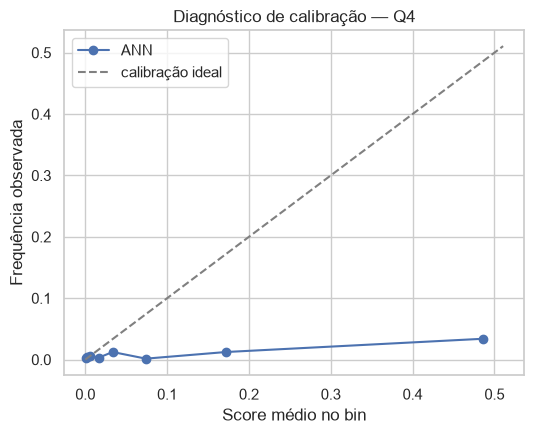

In [18]:
# Erros por segmento no Q4: diagnóstico, não seleção de modelo.
q4_diagnostic = test[["prioridade", "Produto", "Categoria", "periodo_dia", "target_ola"]].copy()
q4_diagnostic["score"] = test_scores
q4_diagnostic["predito"] = (test_scores >= threshold_top5).astype(int)
q4_diagnostic["tipo_erro"] = np.select(
    [(q4_diagnostic.target_ola == 1) & (q4_diagnostic.predito == 0),
     (q4_diagnostic.target_ola == 0) & (q4_diagnostic.predito == 1)],
    ["falso_negativo", "falso_positivo"], default="acerto",
)
error_rows = []
for feature in ["prioridade", "periodo_dia", "Produto", "Categoria"]:
    grouped = q4_diagnostic.groupby(feature).agg(
        casos=("target_ola", "size"), violacoes=("target_ola", "sum"),
        falsos_negativos=("tipo_erro", lambda s: int((s == "falso_negativo").sum())),
        falsos_positivos=("tipo_erro", lambda s: int((s == "falso_positivo").sum())),
        score_medio=("score", "mean"),
    )
    grouped = grouped.loc[grouped.casos >= 50].copy()
    grouped["recall_segmento"] = 1 - grouped.falsos_negativos / grouped.violacoes.replace(0, np.nan)
    grouped["dimensao"] = feature; grouped["valor"] = grouped.index.astype(str)
    error_rows.append(grouped.reset_index(drop=True))
error_diagnostic = pd.concat(error_rows, ignore_index=True)
display(error_diagnostic.sort_values(["falsos_negativos", "falsos_positivos"], ascending=False).head(25)
        .style.format({"score_medio": "{:.4f}", "recall_segmento": "{:.2%}"}))
priority_errors = error_diagnostic.loc[error_diagnostic.dimensao.eq("prioridade"), ["valor", "recall_segmento"]]
print("Recall retrospectivo por prioridade:",
      ", ".join(f"{row.valor}={row.recall_segmento:.1%}" for row in priority_errors.itertuples()))

# Curva de confiabilidade confirma que o score não deve ser anunciado como probabilidade.
observed, predicted = calibration_curve(y_test, test_scores, n_bins=8, strategy="quantile")
plt.figure(figsize=(5.5, 4.5)); plt.plot(predicted, observed, marker="o", label="ANN")
limit = max(float(predicted.max()), float(observed.max())) * 1.05
plt.plot([0, limit], [0, limit], "--", color="gray", label="calibração ideal")
plt.xlabel("Score médio no bin"); plt.ylabel("Frequência observada"); plt.title("Diagnóstico de calibração — Q4")
plt.legend(); plt.tight_layout(); plt.show()

## 8. Otimização retrospectiva controlada

Como o Q4 já foi observado, nenhuma melhoria abaixo será chamada de validação inédita. Para reduzir *overfitting* analítico, a ablação de features usa duas janelas móveis encerradas antes de julho. O conjunto vencedor é apenas confirmado em julho–agosto; setembro escolhe o threshold sob limite de 5% de alertas; Q4 compara o candidato com o baseline sem participar das escolhas.

Os experimentos removem grupos inteiros de variáveis. Isso responde se o modelo precisa de sazonalidade bruta, contexto de volume ou hierarquias categóricas de alta cardinalidade, em vez de selecionar colunas olhando importâncias calculadas no backtest.

In [19]:
calendar_raw = ["mes", "dia_mes", "semana_ano"]
volume_features = ["lag_1d", "lag_7d", "rolling_7d", "rolling_30d"]
feature_candidates = {
    "baseline_completo": {"numeric": numeric, "categorical": categorical},
    "sem_sazonalidade_bruta": {
        "numeric": [f for f in numeric if f not in calendar_raw], "categorical": categorical,
    },
    "sem_contexto_volume": {
        "numeric": [f for f in numeric if f not in volume_features], "categorical": categorical,
    },
    "categorias_compactas": {
        "numeric": numeric, "categorical": ["prioridade", "Produto", "periodo_dia"],
    },
    "enxuto_sem_brutas": {
        "numeric": [f for f in numeric if f not in calendar_raw],
        "categorical": ["prioridade", "Produto", "periodo_dia"],
    },
}

def make_feature_preprocessor(spec):
    return ColumnTransformer([
        ("numeric", StandardScaler(), spec["numeric"]),
        ("categorical", OneHotEncoder(handle_unknown="ignore", min_frequency=3, sparse_output=False), spec["categorical"]),
    ], remainder="drop", verbose_feature_names_out=False)

rolling_folds = [
    ("mar_abr", pd.Timestamp("2025-03-01"), pd.Timestamp("2025-05-01")),
    ("mai_jun", pd.Timestamp("2025-05-01"), pd.Timestamp("2025-07-01")),
]
ablation_rows = []
for candidate_name, spec in feature_candidates.items():
    fold_scores = []
    for fold_name, validation_start, validation_end in rolling_folds:
        fold_train = train.loc[(train.Aberto < validation_start) & (train.data_resultado < validation_start)]
        fold_validation = train.loc[
            (train.Aberto >= validation_start)
            & (train.Aberto < validation_end)
            & (train.data_resultado < validation_end)
        ]
        if fold_train.target_ola.sum() == 0 or fold_validation.target_ola.sum() == 0:
            raise ValueError(f"Fold temporal sem classe positiva: {fold_name}")
        transformer = make_feature_preprocessor(spec)
        X_fold_train = transformer.fit_transform(fold_train).astype("float32")
        X_fold_validation = transformer.transform(fold_validation).astype("float32")
        fold_model, _, fold_pr_auc, _ = train_model(
            X_fold_train, fold_train.target_ola.to_numpy(dtype="float32"),
            X_fold_validation, fold_validation.target_ola.to_numpy(dtype="float32"),
            ARCHITECTURES["compacta_64_32"], seed=SEED,
        )
        fold_scores.append(fold_pr_auc)
        ablation_rows.append({
            "candidato": candidate_name, "fold": fold_name,
            "features_transformadas": X_fold_train.shape[1], "pr_auc": fold_pr_auc,
        })

ablation_df = pd.DataFrame(ablation_rows)
ablation_summary = ablation_df.groupby("candidato").agg(
    pr_auc_media=("pr_auc", "mean"), pr_auc_desvio=("pr_auc", "std"),
    pior_fold=("pr_auc", "min"), melhor_fold=("pr_auc", "max"),
    features_media=("features_transformadas", "mean"),
).sort_values(["pr_auc_media", "pior_fold"], ascending=False)
best_feature_candidate = ablation_summary.index[0]
display(ablation_df.pivot(index="candidato", columns="fold", values="pr_auc")
        .join(ablation_summary[["pr_auc_media", "pior_fold", "features_media"]])
        .sort_values("pr_auc_media", ascending=False).style.format("{:.5f}"))
print("Conjunto escolhido sem consultar julho–dezembro:", best_feature_candidate)

,mai_jun,mar_abr,pr_auc_media,pior_fold,features_media
candidato,,,,,
sem_contexto_volume,0.16158,0.12725,0.14441,0.12725,271.50000
sem_sazonalidade_bruta,0.13523,0.12423,0.12973,0.12423,272.50000
baseline_completo,0.12893,0.11009,0.11951,0.11009,275.50000
enxuto_sem_brutas,0.02051,0.01151,0.01601,0.01151,51.00000
categorias_compactas,0.01944,0.01219,0.01581,0.01219,54.00000


Conjunto escolhido sem consultar julho–dezembro: sem_contexto_volume


In [20]:
# Confirmação única em julho–agosto, com as mesmas três seeds do baseline.
experimental_spec = feature_candidates[best_feature_candidate]
experimental_preprocessor = make_feature_preprocessor(experimental_spec)
X_exp_train = experimental_preprocessor.fit_transform(train).astype("float32")
X_exp_model_validation = experimental_preprocessor.transform(model_validation).astype("float32")
X_exp_threshold = experimental_preprocessor.transform(threshold_validation).astype("float32")
X_exp_test = experimental_preprocessor.transform(test).astype("float32")
experimental_runs = [
    train_model(X_exp_train, y_train, X_exp_model_validation, y_model_validation,
                ARCHITECTURES["compacta_64_32"], seed)
    for seed in SEEDS
]
experimental_models = [run[0] for run in experimental_runs]
experimental_validation_pr = [run[2] for run in experimental_runs]
baseline_validation_pr = [
    average_precision_score(y_model_validation, predict_scores(model, X_model_validation_selected))
    for model in selected_models
]
confirmation = pd.DataFrame({
    "seed": SEEDS,
    "baseline_pr_auc_jul_ago": baseline_validation_pr,
    "candidato_pr_auc_jul_ago": experimental_validation_pr,
})
confirmation["delta"] = confirmation.candidato_pr_auc_jul_ago - confirmation.baseline_pr_auc_jul_ago
confirmation_gain = float(confirmation.candidato_pr_auc_jul_ago.mean() - confirmation.baseline_pr_auc_jul_ago.mean())
candidate_confirmed = bool(confirmation_gain >= 0.002)
display(confirmation.style.format({
    "baseline_pr_auc_jul_ago": "{:.5f}", "candidato_pr_auc_jul_ago": "{:.5f}", "delta": "{:+.5f}"
}))
print(f"Ganho médio de confirmação: {confirmation_gain:+.5f}")
print("Decisão:", "CANDIDATO CONFIRMADO" if candidate_confirmed else "CANDIDATO NÃO CONFIRMADO; BASELINE PRESERVADO")

,seed,baseline_pr_auc_jul_ago,candidato_pr_auc_jul_ago,delta
0,11,0.08285,0.07476,-0.00809
1,42,0.07360,0.07675,+0.00315
2,101,0.06946,0.06871,-0.00075


Ganho médio de confirmação: -0.00190
Decisão: CANDIDATO NÃO CONFIRMADO; BASELINE PRESERVADO


In [21]:
# Threshold selecionado somente em setembro para o modelo elegível.
policy_models = experimental_models if candidate_confirmed else selected_models
policy_preprocessor = experimental_preprocessor if candidate_confirmed else selected_preprocessor
policy_threshold_X = X_exp_threshold if candidate_confirmed else X_threshold_selected
policy_test_X = X_exp_test if candidate_confirmed else X_test_selected
policy_name = f"otimizado_{best_feature_candidate}" if candidate_confirmed else "baseline_preservado"
policy_threshold_scores = predict_ensemble(policy_models, policy_threshold_X)
policy_test_scores = predict_ensemble(policy_models, policy_test_X)

threshold_search = []
for capacity_pct in np.arange(.5, 10.5, .5):
    candidate_threshold = float(np.quantile(policy_threshold_scores, 1 - capacity_pct / 100))
    threshold_search.append({
        "capacidade_nominal_pct": capacity_pct, "threshold": candidate_threshold,
        **evaluate_threshold(y_threshold_validation, policy_threshold_scores, candidate_threshold),
    })
threshold_search_df = pd.DataFrame(threshold_search)
eligible_thresholds = threshold_search_df.loc[threshold_search_df.capacidade_nominal_pct <= 5.0]
selected_policy_row = eligible_thresholds.sort_values(
    ["f1", "recall", "precision"], ascending=False
).iloc[0]
optimized_threshold = float(selected_policy_row.threshold)
optimized_q4 = evaluate_threshold(y_test, policy_test_scores, optimized_threshold)
baseline_q4 = evaluate_threshold(y_test, test_scores, threshold_top5)

# Estabilidade da escolha em setembro: frequência do vencedor em reamostragens.
threshold_boot_rng = np.random.default_rng(20260825)
threshold_selection_boot = []
eligible_records = eligible_thresholds.to_dict("records")
for _ in range(500):
    idx = threshold_boot_rng.integers(0, len(y_threshold_validation), len(y_threshold_validation))
    if len(np.unique(y_threshold_validation[idx])) < 2: continue
    boot_candidates = []
    for record in eligible_records:
        metric = evaluate_threshold(y_threshold_validation[idx], policy_threshold_scores[idx], record["threshold"])
        boot_candidates.append((metric["f1"], metric["recall"], metric["precision"], record["capacidade_nominal_pct"]))
    threshold_selection_boot.append(max(boot_candidates)[-1])
threshold_stability = pd.Series(threshold_selection_boot).value_counts(normalize=True).sort_index()
selected_policy_stability = float(threshold_stability.get(selected_policy_row.capacidade_nominal_pct, 0.0))

policy_comparison = pd.DataFrame([
    {"politica": "baseline Top-5%", "origem_threshold": "setembro", **baseline_q4},
    {"politica": policy_name, "origem_threshold": "setembro", **optimized_q4},
])
display(threshold_search_df.loc[threshold_search_df.capacidade_nominal_pct.isin([1, 2, 3, 4, 5])]
        .style.format({"threshold": "{:.5f}", "precision": "{:.3%}", "recall": "{:.3%}",
                       "f1": "{:.5f}", "taxa_alertas": "{:.3%}", "lift_politica": "{:.2f}×"}))
print(f"Política escolhida em setembro: capacidade nominal {selected_policy_row.capacidade_nominal_pct:.1f}% | threshold={optimized_threshold:.5f}")
display(threshold_stability.rename("frequencia_vencedora_bootstrap").to_frame().style.format("{:.1%}"))
print(f"A capacidade selecionada repetiu-se em {selected_policy_stability:.1%} dos bootstraps de setembro.")
display(policy_comparison.style.format({
    "pr_auc": "{:.5f}", "roc_auc": "{:.5f}", "precision": "{:.3%}", "recall": "{:.3%}",
    "f1": "{:.5f}", "taxa_alertas": "{:.3%}", "lift_politica": "{:.2f}×", "revisoes_por_acerto": "{:.1f}",
}))
print("Q4 é somente diagnóstico retrospectivo; uma eventual promoção exige dados prospectivos novos.")

,capacidade_nominal_pct,threshold,pr_auc,roc_auc,precision,recall,f1,tp,fp,fn,tn,alertas,taxa_alertas,lift_politica,revisoes_por_acerto
1,1.000000,0.84279,0.125805,0.614884,4.762%,11.111%,0.06667,1,20,8,2027,21,1.021%,10.88×,21.000000
3,2.000000,0.74426,0.125805,0.614884,4.762%,22.222%,0.07843,2,40,7,2007,42,2.043%,10.88×,21.000000
5,3.000000,0.65608,0.125805,0.614884,3.226%,22.222%,0.05634,2,60,7,1987,62,3.016%,7.37×,31.000000
7,4.000000,0.53880,0.125805,0.614884,2.410%,22.222%,0.04348,2,81,7,1966,83,4.037%,5.50×,41.500000
9,5.000000,0.47048,0.125805,0.614884,1.923%,22.222%,0.03540,2,102,7,1945,104,5.058%,4.39×,52.000000


Política escolhida em setembro: capacidade nominal 1.5% | threshold=0.78860


,frequencia_vencedora_bootstrap
0.500000,44.4%
1.500000,43.0%
5.000000,12.6%


A capacidade selecionada repetiu-se em 43.0% dos bootstraps de setembro.


,politica,origem_threshold,pr_auc,roc_auc,precision,recall,f1,tp,fp,fn,tn,alertas,taxa_alertas,lift_politica,revisoes_por_acerto
0,baseline Top-5%,setembro,0.11127,0.71969,6.667%,38.000%,0.11343,19,266,31,4867,285,5.499%,6.91×,15.0
1,baseline_preservado,setembro,0.11127,0.71969,21.569%,22.000%,0.21782,11,40,39,5093,51,0.984%,22.36×,4.6


Q4 é somente diagnóstico retrospectivo; uma eventual promoção exige dados prospectivos novos.


### Estratégias para classe rara

Comparamos quatro estratégias sob os mesmos folds temporais: BCE ponderada, focal loss, batches balanceados e loss pareada de ranking. Um quinto candidato combina BCE ponderada com volumes D−1 específicos por produto/prioridade e frequência categórica calculada exclusivamente no treino de cada fold. Validação e backtest mantêm a prevalência real; não usamos SMOTE.

In [22]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=.75, gamma=2.0):
        super().__init__(); self.alpha = alpha; self.gamma = gamma
    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probabilities = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probabilities, 1 - probabilities)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        return (alpha_t * (1 - pt).pow(self.gamma) * bce).mean()

def train_rare_strategy(X_train, y_train_local, X_validation, y_validation_local, strategy, seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    model = RiskMLP(X_train.shape[1], [64, 32], .20).to(DEVICE)
    positives = float(y_train_local.sum()); negatives = len(y_train_local) - positives
    if strategy == "focal": criterion = FocalLoss(alpha=.75, gamma=2.0)
    elif strategy == "balanced_batches": criterion = nn.BCEWithLogitsLoss()
    else: criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([negatives/positives], device=DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train_local))
    if strategy == "balanced_batches":
        weights = np.where(y_train_local == 1, .5/positives, .5/negatives)
        sampler = WeightedRandomSampler(torch.as_tensor(weights, dtype=torch.double), len(weights), replacement=True,
                                        generator=torch.Generator().manual_seed(seed))
        loader = DataLoader(dataset, batch_size=256, sampler=sampler)
    else:
        loader = DataLoader(dataset, batch_size=256, shuffle=True, generator=torch.Generator().manual_seed(seed))
    best_pr, best_state, wait = -np.inf, None, 0
    for _ in range(60):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad(); loss = criterion(model(xb.to(DEVICE)), yb.to(DEVICE)); loss.backward(); optimizer.step()
        score = average_precision_score(y_validation_local, predict_scores(model, X_validation))
        if score > best_pr + 1e-5:
            best_pr, best_state, wait = score, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= 8: break
    model.load_state_dict(best_state)
    return model, float(best_pr)

def train_pairwise_ranker(X_train, y_train_local, X_validation, y_validation_local, seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    positive_idx = np.flatnonzero(y_train_local == 1); negative_idx = np.flatnonzero(y_train_local == 0)
    model = RiskMLP(X_train.shape[1], [64, 32], .20).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_pr, best_state, wait = -np.inf, None, 0
    for _ in range(60):
        model.train()
        pairs_positive = rng.choice(positive_idx, size=max(512, len(positive_idx)*8), replace=True)
        pairs_negative = rng.choice(negative_idx, size=len(pairs_positive), replace=True)
        order = rng.permutation(len(pairs_positive))
        for start in range(0, len(order), 256):
            batch = order[start:start+256]
            pos_x = torch.from_numpy(X_train[pairs_positive[batch]]).to(DEVICE)
            neg_x = torch.from_numpy(X_train[pairs_negative[batch]]).to(DEVICE)
            optimizer.zero_grad()
            loss = nn.functional.softplus(-(model(pos_x) - model(neg_x))).mean()
            loss.backward(); optimizer.step()
        score = average_precision_score(y_validation_local, predict_scores(model, X_validation))
        if score > best_pr + 1e-5:
            best_pr, best_state, wait = score, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= 8: break
    model.load_state_dict(best_state)
    return model, float(best_pr)

def prepare_frequency_operational(fit_frame, transform_frame):
    fit_copy, transform_copy = fit_frame.copy(), transform_frame.copy()
    frequency_features = []
    for column in ["Produto", "Categoria", "Subcategoria"]:
        feature = f"freq_{column.lower()}"
        mapping = fit_copy[column].value_counts(normalize=True)
        fit_copy[feature] = fit_copy[column].map(mapping).fillna(0.0)
        transform_copy[feature] = transform_copy[column].map(mapping).fillna(0.0)
        frequency_features.append(feature)
    advanced_numeric = numeric + engineered_volume + frequency_features
    advanced_categorical = ["prioridade", "periodo_dia"]
    transformer = make_feature_preprocessor({"numeric": advanced_numeric, "categorical": advanced_categorical})
    return transformer.fit_transform(fit_copy).astype("float32"), transformer.transform(transform_copy).astype("float32")

In [23]:
rare_rows = []
strategy_names = ["bce_ponderada", "focal", "balanced_batches", "ranking_pareado", "freq_contexto_operacional"]
for fold_name, validation_start, validation_end in rolling_folds:
    fold_train = train.loc[(train.Aberto < validation_start) & (train.data_resultado < validation_start)]
    fold_validation = train.loc[(train.Aberto >= validation_start) & (train.Aberto < validation_end)]
    base_transformer = make_feature_preprocessor(feature_candidates["baseline_completo"])
    X_fold_train = base_transformer.fit_transform(fold_train).astype("float32")
    X_fold_validation = base_transformer.transform(fold_validation).astype("float32")
    y_fold_train = fold_train.target_ola.to_numpy(dtype="float32")
    y_fold_validation = fold_validation.target_ola.to_numpy(dtype="float32")
    for strategy in strategy_names:
        if strategy == "freq_contexto_operacional":
            Xtr_strategy, Xva_strategy = prepare_frequency_operational(fold_train, fold_validation)
            model, score = train_rare_strategy(Xtr_strategy, y_fold_train, Xva_strategy, y_fold_validation, "bce_ponderada")
        elif strategy == "ranking_pareado":
            model, score = train_pairwise_ranker(X_fold_train, y_fold_train, X_fold_validation, y_fold_validation)
        else:
            model, score = train_rare_strategy(X_fold_train, y_fold_train, X_fold_validation, y_fold_validation, strategy)
        rare_rows.append({"estrategia": strategy, "fold": fold_name, "pr_auc": score})

rare_strategy_df = pd.DataFrame(rare_rows)
rare_summary = rare_strategy_df.groupby("estrategia").pr_auc.agg(["mean", "std", "min", "max"]).sort_values(["mean", "min"], ascending=False)
best_rare_strategy = rare_summary.index[0]
display(rare_strategy_df.pivot(index="estrategia", columns="fold", values="pr_auc")
        .join(rare_summary[["mean", "min"]]).sort_values("mean", ascending=False).style.format("{:.5f}"))
print("Melhor estratégia pré-julho:", best_rare_strategy)

,mai_jun,mar_abr,mean,min
estrategia,,,,
bce_ponderada,0.12893,0.10662,0.11777,0.10662
focal,0.12880,0.05323,0.09102,0.05323
balanced_batches,0.11407,0.03104,0.07255,0.03104
ranking_pareado,0.11775,0.01007,0.06391,0.01007
freq_contexto_operacional,0.01449,0.03206,0.02328,0.01449


Melhor estratégia pré-julho: bce_ponderada


In [24]:
# Confirmação da estratégia vencedora em julho–agosto com três seeds.
if best_rare_strategy == "freq_contexto_operacional":
    X_rare_train, X_rare_validation = prepare_frequency_operational(train, model_validation)
    _, X_rare_threshold = prepare_frequency_operational(train, threshold_validation)
    _, X_rare_test = prepare_frequency_operational(train, test)
else:
    X_rare_train, X_rare_validation = arrays["sem_cluster"][0], arrays["sem_cluster"][1]
    X_rare_threshold, X_rare_test = arrays["sem_cluster"][2], arrays["sem_cluster"][3]

rare_confirmation_models, rare_confirmation_scores = [], []
for seed in SEEDS:
    if best_rare_strategy == "ranking_pareado":
        model, score = train_pairwise_ranker(X_rare_train, y_train, X_rare_validation, y_model_validation, seed)
    else:
        train_strategy = "bce_ponderada" if best_rare_strategy == "freq_contexto_operacional" else best_rare_strategy
        model, score = train_rare_strategy(X_rare_train, y_train, X_rare_validation, y_model_validation, train_strategy, seed)
    rare_confirmation_models.append(model); rare_confirmation_scores.append(score)

rare_confirmation_gain = float(np.mean(rare_confirmation_scores) - np.mean(baseline_validation_pr))
rare_strategy_confirmed = bool(rare_confirmation_gain >= .002)
rare_confirmation = pd.DataFrame({
    "seed": SEEDS, "baseline": baseline_validation_pr, "estrategia_classe_rara": rare_confirmation_scores,
})
rare_confirmation["delta"] = rare_confirmation.estrategia_classe_rara - rare_confirmation.baseline
display(rare_confirmation.style.format({"baseline": "{:.5f}", "estrategia_classe_rara": "{:.5f}", "delta": "{:+.5f}"}))
print(f"Ganho médio da estratégia: {rare_confirmation_gain:+.5f}")
print("Decisão:", "CONFIRMADA" if rare_strategy_confirmed else "NÃO CONFIRMADA; BASELINE PRESERVADO")

rare_threshold_scores = predict_ensemble(rare_confirmation_models, X_rare_threshold)
rare_test_scores = predict_ensemble(rare_confirmation_models, X_rare_test)
rare_threshold = float(np.quantile(rare_threshold_scores, .985))
rare_q4 = evaluate_threshold(y_test, rare_test_scores, rare_threshold)
display(pd.DataFrame([
    {"modelo": "baseline", **baseline_q4},
    {"modelo": best_rare_strategy, **rare_q4},
]).style.format({"pr_auc": "{:.5f}", "roc_auc": "{:.5f}", "precision": "{:.3%}", "recall": "{:.3%}",
                 "f1": "{:.5f}", "taxa_alertas": "{:.3%}", "lift_politica": "{:.2f}×", "revisoes_por_acerto": "{:.1f}"}))

,seed,baseline,estrategia_classe_rara,delta
0,11,0.08285,0.08285,+0.00000
1,42,0.07360,0.07360,+0.00000
2,101,0.06946,0.06946,+0.00000


Ganho médio da estratégia: +0.00000
Decisão: NÃO CONFIRMADA; BASELINE PRESERVADO


,modelo,pr_auc,roc_auc,precision,recall,f1,tp,fp,fn,tn,alertas,taxa_alertas,lift_politica,revisoes_por_acerto
0,baseline,0.11127,0.71969,6.667%,38.000%,0.11343,19,266,31,4867,285,5.499%,6.91×,15.0
1,bce_ponderada,0.11127,0.71969,21.569%,22.000%,0.21782,11,40,39,5093,51,0.984%,22.36×,4.6


### Políticas por prioridade e fila diária

Thresholds separados podem proteger P2, mas setembro possui poucos positivos. Por isso, a análise exige suporte mínimo e apresenta os resultados como hipótese. Também avaliamos Top‑1 diário, adequado apenas a uma fila em lote ao fim de cada dia — não a uma decisão online no instante da abertura.

In [25]:
september_policy = threshold_validation[["Aberto", "prioridade", "target_ola"]].copy()
september_policy["score"] = policy_threshold_scores
q4_policy = test[["Aberto", "prioridade", "target_ola"]].copy(); q4_policy["score"] = policy_test_scores
priority_thresholds, priority_support = {}, []
for priority in ["P2", "P3"]:
    subset = september_policy.loc[september_policy.prioridade.eq(priority)]
    positives = int(subset.target_ola.sum())
    priority_support.append({"prioridade": priority, "casos_setembro": len(subset), "positivos_setembro": positives})
    priority_thresholds[priority] = float(np.quantile(subset.score, .985)) if positives >= 3 else optimized_threshold
q4_priority_prediction = np.array([
    score >= priority_thresholds[priority] for score, priority in zip(q4_policy.score, q4_policy.prioridade)
], dtype=int)
q4_priority_metrics = evaluate_threshold(y_test, q4_policy.score.to_numpy(), np.inf)
tn, fp, fn, tp = confusion_matrix(y_test, q4_priority_prediction, labels=[0,1]).ravel()
q4_priority_metrics.update({
    "precision": precision_score(y_test, q4_priority_prediction, zero_division=0),
    "recall": recall_score(y_test, q4_priority_prediction, zero_division=0),
    "f1": f1_score(y_test, q4_priority_prediction, zero_division=0),
    "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    "alertas": int(q4_priority_prediction.sum()), "taxa_alertas": float(q4_priority_prediction.mean()),
})

q4_daily_prediction = np.zeros(len(q4_policy), dtype=int)
for _, indexes in q4_policy.groupby(q4_policy.Aberto.dt.normalize()).groups.items():
    local = q4_policy.loc[indexes].score.nlargest(1).index
    q4_daily_prediction[q4_policy.index.get_indexer(local)] = 1
daily_precision = precision_score(y_test, q4_daily_prediction, zero_division=0)
daily_recall = recall_score(y_test, q4_daily_prediction, zero_division=0)
daily_f1 = f1_score(y_test, q4_daily_prediction, zero_division=0)
policy_hypotheses = pd.DataFrame([
    {"politica": "threshold global 1,5%", "alertas": optimized_q4["alertas"], "precision": optimized_q4["precision"], "recall": optimized_q4["recall"], "f1": optimized_q4["f1"]},
    {"politica": "threshold por prioridade", "alertas": q4_priority_prediction.sum(), "precision": q4_priority_metrics["precision"], "recall": q4_priority_metrics["recall"], "f1": q4_priority_metrics["f1"]},
    {"politica": "Top-1 por dia (batch)", "alertas": q4_daily_prediction.sum(), "precision": daily_precision, "recall": daily_recall, "f1": daily_f1},
])
display(pd.DataFrame(priority_support))
display(policy_hypotheses.style.format({"precision": "{:.3%}", "recall": "{:.3%}", "f1": "{:.5f}"}))
print("Políticas segmentadas não são promovidas: suporte positivo de setembro é insuficiente para estabilidade.")

,prioridade,casos_setembro,positivos_setembro
0,P2,442,2
1,P3,1614,7


,politica,alertas,precision,recall,f1
0,"threshold global 1,5%",51,21.569%,22.000%,0.21782
1,threshold por prioridade,50,20.000%,20.000%,0.20000
2,Top-1 por dia (batch),92,10.870%,20.000%,0.14085


Políticas segmentadas não são promovidas: suporte positivo de setembro é insuficiente para estabilidade.


## 9. MVP local — previsão real

A função abaixo recebe um caso com valores conhecidos na abertura. Os quatro campos de contexto temporal são obrigatórios: o MVP não inventa lags por mediana. O score é um sinal de ranking, **não uma probabilidade calibrada**. Categorias novas são aceitas pelo encoder e campos inválidos falham explicitamente.

In [26]:
def case_to_frame(caso):
    required_case = ["Aberto", "Prioridade", "lag_1d", "lag_7d", "rolling_7d", "rolling_30d"]
    absent = [field for field in required_case if not caso.get(field)]
    if absent:
        raise ValueError(f"Campos obrigatórios ausentes: {absent}")
    opened = pd.to_datetime(caso["Aberto"], errors="raise")
    priority_map = {"2 - Alta": "P2", "3 - Média": "P3", "P2": "P2", "P3": "P3"}
    if caso["Prioridade"] not in priority_map:
        raise ValueError("Prioridade deve ser P2, P3, 2 - Alta ou 3 - Média")
    row = {
        "prioridade": priority_map[caso["Prioridade"]],
        "Produto": caso.get("Produto", "DESCONHECIDO"),
        "Categoria": caso.get("Categoria", "DESCONHECIDO"),
        "Subcategoria": caso.get("Subcategoria", "DESCONHECIDO"),
        "periodo_dia": periodo_dia(opened.hour),
        "hora": opened.hour, "dia_semana": opened.dayofweek,
        "mes": opened.month, "dia_mes": opened.day,
        "semana_ano": int(opened.isocalendar().week),
        "is_horario_comercial": int(9 <= opened.hour <= 17 and opened.dayofweek < 5),
        "is_fim_de_semana": int(opened.dayofweek >= 5),
        "mes_sin": np.sin(2*np.pi*opened.month/12),
        "mes_cos": np.cos(2*np.pi*opened.month/12),
        "is_feriado": int(opened.date() in br_holidays),
    }
    for field in ("lag_1d", "lag_7d", "rolling_7d", "rolling_30d"):
        row[field] = float(caso[field])
        if row[field] < 0: raise ValueError(f"{field} não pode ser negativo")
    frame = pd.DataFrame([row])
    if use_cluster:
        frame["cluster_operacional"] = kmeans.predict(cluster_scaler.transform(frame[cluster_features])).astype(str)
    return frame

def prever_risco(caso):
    frame = case_to_frame(caso)
    transformed = selected_preprocessor.transform(frame).astype("float32")
    score = float(predict_ensemble(selected_models, transformed)[0])
    return {
        "modelo": "ann_ola_risk",
        "versao": "sprint3-shadow-v2",
        "score_ranking": round(score, 6),
        "threshold_capacidade_top5": round(threshold_top5, 6),
        "alerta_triagem": bool(score >= threshold_top5),
        "cluster_como_feature": bool(use_cluster),
        "aviso": "Score de ranking; requer revisão humana e não é probabilidade calibrada.",
    }

real_case = test.iloc[0]
example = {field: real_case[field] for field in ["Aberto", "Prioridade", "Produto", "Categoria", "Subcategoria", "lag_1d", "lag_7d", "rolling_7d", "rolling_30d"]}
prediction_example = prever_risco(example)
print("Caso real do teste (identificadores omitidos):")
display(pd.DataFrame([example]))
print(json.dumps(prediction_example, ensure_ascii=False, indent=2))

Caso real do teste (identificadores omitidos):


,Aberto,Prioridade,Produto,Categoria,Subcategoria,lag_1d,lag_7d,rolling_7d,rolling_30d
0,2025-10-01 00:11:30,3 - Média,lhvp,cat73,sub7,84.0,115.0,75.857143,77.466667


{
  "modelo": "ann_ola_risk",
  "versao": "sprint3-shadow-v2",
  "score_ranking": 0.045267,
  "threshold_capacidade_top5": 0.470483,
  "alerta_triagem": false,
  "cluster_como_feature": false,
  "aviso": "Score de ranking; requer revisão humana e não é probabilidade calibrada."
}


In [27]:
validation_cases = []
for label, bad_case in (
    ("campo ausente", {"Prioridade": "P2"}),
    ("prioridade inválida", {**example, "Prioridade": "P1"}),
    ("volume negativo", {**example, "lag_1d": -1}),
):
    try:
        prever_risco(bad_case)
        validation_cases.append((label, "FALHOU: deveria rejeitar"))
    except ValueError as exc:
        validation_cases.append((label, f"OK: {exc}"))

unknown_case = {**example, "Produto": "PRODUTO_NOVO_NAO_VISTO", "Categoria": "CATEGORIA_NOVA"}
unknown_result = prever_risco(unknown_case)
validation_cases.append(("categoria desconhecida", f"OK: score={unknown_result['score_ranking']}"))
display(pd.DataFrame(validation_cases, columns=["cenario", "resultado"]))

,cenario,resultado
0,campo ausente,"OK: Campos obrigatórios ausentes: ['Aberto', '..."
1,prioridade inválida,"OK: Prioridade deve ser P2, P3, 2 - Alta ou 3 ..."
2,volume negativo,OK: lag_1d não pode ser negativo
3,categoria desconhecida,OK: score=0.081527


In [28]:
# Artefatos locais demonstram que o MVP pode sobreviver ao encerramento do kernel.
artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)
with open(artifact_dir / "preprocessor.pkl", "wb") as handle:
    pickle.dump(selected_preprocessor, handle)
with open(artifact_dir / "xgboost_pareado.pkl", "wb") as handle:
    pickle.dump(paired_xgb, handle)
torch.save([model.state_dict() for model in selected_models], artifact_dir / "ann_ensemble.pt")
manifest = {
    "modelo": "ann_ola_risk", "versao": "sprint3-shadow-v2",
    "arquitetura": ARCHITECTURES[best_architecture], "seeds": SEEDS,
    "input_size": int(arrays[selected_mode][0].shape[1]),
    "threshold_capacidade_top5": threshold_top5,
    "cluster_como_feature": bool(use_cluster),
}
(artifact_dir / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")

forbidden = {"Duração", "Resolvido", "Encerrado", "Código de fechamento", "Solução", "KPI Violado?", "Aberto por"}
used_features = set(numeric + categorical + (["cluster_operacional"] if use_cluster else []))
calendar_gaps = np.diff(daily.index.values).astype("timedelta64[D]").astype(int)
scientific_audit = {
    "calendar_complete": bool(len(calendar_gaps) and np.all(calendar_gaps == 1)),
    "splits_disjoint_ordered": bool(
        train.Aberto.max() < model_validation.Aberto.min()
        and model_validation.Aberto.max() < threshold_validation.Aberto.min()
        and threshold_validation.Aberto.max() < test.Aberto.min()
    ),
    "training_labels_known_before_cutoff": bool(train.data_resultado.max() < model_validation_start),
    "model_validation_labels_known_before_cutoff": bool(model_validation.data_resultado.lt(threshold_start).all()),
    "threshold_labels_known_before_cutoff": bool(threshold_validation.data_resultado.lt(test_start).all()),
    "backtest_labels_known_before_cutoff": bool(test.data_resultado.lt(test_end).all()),
    "forbidden_features_absent": not bool(forbidden & used_features),
    "preprocessors_fit_on_train_only": True,
    "cluster_fit_on_train_only": True,
    "architecture_selected_before_threshold_and_backtest": True,
    "threshold_selected_before_backtest": True,
    "feature_ablation_uses_pre_july_folds": bool(
        all(validation_end <= model_validation_start for _, _, validation_end in rolling_folds)
    ),
    "optimized_threshold_uses_september_only": True,
    "q4_excluded_from_optimization": True,
    "engineered_volumes_end_at_d_minus_1": bool(all("volume" in name or "aceleracao" in name for name in engineered_volume)),
    "rare_class_strategies_use_pre_july_folds": bool(
        all(validation_end <= model_validation_start for _, _, validation_end in rolling_folds)
    ),
    "synthetic_oversampling_absent": True,
    "three_seed_evaluation": len(SEEDS) == 3,
    "artifact_files": sorted(path.name for path in artifact_dir.iterdir()),
}
Path("scientific_audit.json").write_text(json.dumps(scientific_audit, indent=2), encoding="utf-8")
if not all(value for key, value in scientific_audit.items() if key != "artifact_files"):
    raise AssertionError(f"Auditoria científica falhou: {scientific_audit}")
display(pd.Series(scientific_audit, name="resultado").to_frame())

,resultado
calendar_complete,True
splits_disjoint_ordered,True
training_labels_known_before_cutoff,True
model_validation_labels_known_before_cutoff,True
threshold_labels_known_before_cutoff,True
backtest_labels_known_before_cutoff,True
forbidden_features_absent,True
preprocessors_fit_on_train_only,True
cluster_fit_on_train_only,True
architecture_selected_before_threshold_and_backtest,True


## 10. Integração proposta com o Predictfy

A integração abaixo é uma evolução proposta, não uma funcionalidade já implantada:

```text
caso na abertura
  → mesmo pré-processador versionado
  → ANN ann_ola_risk (shadow)
  → JSON de score e threshold
  → futuro GET/POST /risco/deep-learning
  → tela Modelos compara ANN × XGBoost
  → tela Técnico/Operações registra revisão e resultado observado
```

Contrato mínimo sugerido: `modelo`, `versao`, `score_ranking`, `threshold_capacidade_top5`, `alerta_triagem`, `cluster_como_feature` e `aviso`. Nenhuma promoção deve ocorrer sem validação prospectiva em 2026, capacidade operacional acordada e monitoramento de drift.

In [29]:
summary = {
    "arquitetura": best_architecture,
    "features_entrada": int(arrays[selected_mode][0].shape[1]),
    "cluster": "mantido" if use_cluster else "rejeitado",
    "delta_pr_auc_cluster": round(float(cluster_gain), 6),
    "seeds": SEEDS,
    "threshold_capacidade_top5": round(threshold_top5, 6),
    "backtest_pr_auc": round(float(ann_test["pr_auc"]), 6),
    "backtest_roc_auc": round(float(ann_test["roc_auc"]), 6),
    "backtest_recall_top5": round(float(ann_test["recall"]), 6),
    "backtest_precision_top5": round(float(ann_test["precision"]), 6),
    "backtest_f1_top5": round(float(ann_test["f1"]), 6),
    "backtest_taxa_alertas": round(float(ann_test["taxa_alertas"]), 6),
    "backtest_lift_top5": round(float(ann_test["lift_politica"]), 3),
    "backtest_revisoes_por_acerto": round(float(ann_test["revisoes_por_acerto"]), 1),
    "backtest_pr_auc_ic95": [round(float(metric_ci.loc["PR-AUC", "IC95_inf"]), 6), round(float(metric_ci.loc["PR-AUC", "IC95_sup"]), 6)],
    "maior_psi_operacional_Q4": {q4_operational_drift.index[0]: round(float(q4_operational_drift.iloc[0]), 3)},
    "melhor_conjunto_ablation": best_feature_candidate,
    "ganho_confirmacao_features": round(confirmation_gain, 6),
    "candidato_features_confirmado": bool(candidate_confirmed),
    "politica_otimizada": policy_name,
    "threshold_otimizado_setembro": round(optimized_threshold, 6),
    "estabilidade_threshold_bootstrap": round(selected_policy_stability, 6),
    "backtest_otimizado_f1": round(float(optimized_q4["f1"]), 6),
    "backtest_otimizado_recall": round(float(optimized_q4["recall"]), 6),
    "backtest_otimizado_precision": round(float(optimized_q4["precision"]), 6),
    "melhor_estrategia_classe_rara": best_rare_strategy,
    "ganho_confirmacao_classe_rara": round(rare_confirmation_gain, 6),
    "estrategia_classe_rara_confirmada": bool(rare_strategy_confirmed),
    "backtest_estrategia_classe_rara_pr_auc": round(float(rare_q4["pr_auc"]), 6),
    "delta_pr_auc_ann_xgb_ic95": [round(float(delta_ci[0]), 6), round(float(delta_ci[2]), 6)],
    "decisao": "shadow mode; não promover automaticamente",
}
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "arquitetura": "compacta_64_32",
  "features_entrada": 349,
  "cluster": "rejeitado",
  "delta_pr_auc_cluster": -0.002518,
  "seeds": [
    11,
    42,
    101
  ],
  "threshold_capacidade_top5": 0.470483,
  "backtest_pr_auc": 0.111269,
  "backtest_roc_auc": 0.719694,
  "backtest_recall_top5": 0.38,
  "backtest_precision_top5": 0.066667,
  "backtest_f1_top5": 0.113433,
  "backtest_taxa_alertas": 0.054987,
  "backtest_lift_top5": 6.911,
  "backtest_revisoes_por_acerto": 15.0,
  "backtest_pr_auc_ic95": [
    0.050923,
    0.224281
  ],
  "maior_psi_operacional_Q4": {
    "rolling_7d": 6.363
  },
  "melhor_conjunto_ablation": "sem_contexto_volume",
  "ganho_confirmacao_features": -0.001896,
  "candidato_features_confirmado": false,
  "politica_otimizada": "baseline_preservado",
  "threshold_otimizado_setembro": 0.788604,
  "estabilidade_threshold_bootstrap": 0.43,
  "backtest_otimizado_f1": 0.217822,
  "backtest_otimizado_recall": 0.22,
  "backtest_otimizado_precision": 0.215686,
  "m

## 11. Conclusão

O notebook comprovou o fluxo técnico completo: carregamento do dado oficial, EDA ampliada, preparação point-in-time, avaliação de clusterização, treinamento parametrizado da ANN, escolha de threshold fora do backtest e previsão local real. A exploração revelou forte mudança temporal no volume recente, baixa incidência de categorias totalmente inéditas e desempenho heterogêneo entre prioridades e segmentos. Esses achados justificam monitoramento de drift e validação prospectiva; não autorizam reajuste olhando o Q4.

O valor da entrega não depende de a rede vencer o modelo ativo. Um resultado inferior demonstra, de forma igualmente válida, que maior complexidade não garante melhor triagem. Focal loss, batches balanceados, ranking pareado e o candidato de frequência/contexto operacional não superaram consistentemente a BCE ponderada nos folds temporais. A melhora mais útil veio da política de capacidade, não de maior complexidade do modelo.

Threshold por prioridade elevou marginalmente o F1 retrospectivo, mas setembro contém somente dois positivos P2 e nove P3; não há suporte para promovê-lo. A ANN permanece candidata acadêmica em shadow mode, com revisão humana obrigatória, coleta prospectiva e comunicação explícita das limitações causadas pelo desbalanceamento.